Building a function to perform the suzuki-trotter method, so able to explore different time steps, etc easily.

In [1]:
import qiskit
from qiskit import QuantumCircuit
import qiskit.quantum_info as qi
from qiskit.compiler import transpile
from qiskit.circuit.library import StatePreparation
from qiskit.primitives import StatevectorSampler
from qiskit import QuantumRegister, AncillaRegister
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import json
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import functools as ft

In [2]:
from qiskit.primitives import StatevectorEstimator

In [3]:
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import SuzukiTrotter


In [4]:
import Hamiltonian as hm

SparsePauliOp(['IIXX', 'IIYY', 'IIZZ', 'IXXI', 'IYYI', 'IZZI', 'XXII', 'YYII', 'ZZII'],
              coeffs=[-1. +0.j, -1. +0.j, -1.1+0.j, -1. +0.j, -1. +0.j, -1.1+0.j, -1. +0.j,
 -1. +0.j, -1.1+0.j])


In [5]:
L=4
Jz=1.1
hamiltonian = hm.hamiltonian1(L,Jz)

In [6]:
# hamiltonian?

In [7]:
# PauliEvolutionGate?

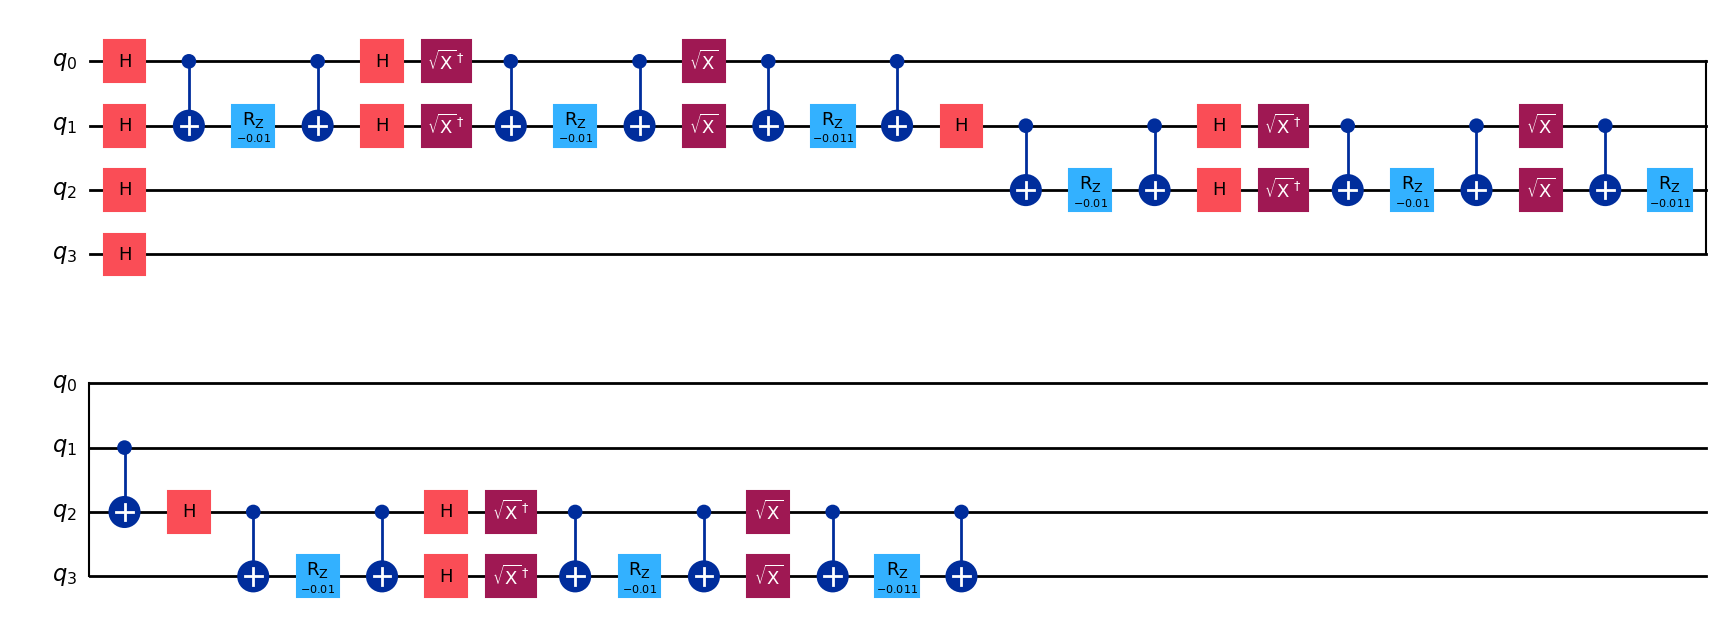

In [8]:
dt = 0.5 * 1e-2
gate = PauliEvolutionGate(operator=hamiltonian,time=dt)

st = SuzukiTrotter(order=1, reps=1)   #whats the advantage of doing reps here vs. appending on then measuring? I guess can only measure every reps?
# in real life, fix circuit depth/trotter circuit, then change dt to get data for different times
circ = st.synthesize(gate)

circ.decompose().draw("mpl")

Okay actually running it and measuring

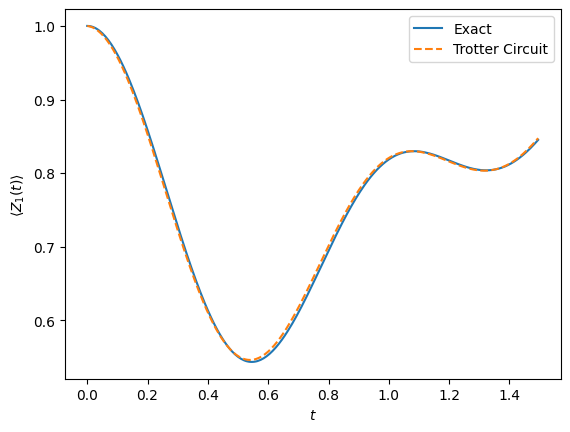

In [9]:
# Define the 'Estimator' primitive used to measure/estimate expectation values of observables
estimator = StatevectorEstimator()

# Define the observable we wish to estimate
z_obs = SparsePauliOp(["ZIII"],coeffs=[1])  #just Z_1 for now

# Initialise circuit
qc = QuantumCircuit(int(L))
all0, all1 = hm.initialise(Jz,L)[1] #this format only works for J_z > 1 because spits out two in a list
qc.initialize(all0)
#apply rotation
middle = L //2 #picks L/2 int value
qc.ry(np.pi/2, middle) #rotation here is into x-y plane
initial = Statevector(qc)  #initial state, now rotated

#resetting qc with new initial state?
qc = QuantumCircuit(int(L))
qc.initialize(initial)

#test
# qc = QuantumCircuit(4)
# qc.x(0)

# Define a single Suzuki-Trotter timestep
st = SuzukiTrotter(order=1, reps=1)
circ = st.synthesize(gate) #creates the ST circuit??

# Prepare an empty list to store data and run a loop over timesteps
zlist2 = []
for t in range(300):
    qc.append(circ,[0,1,2,3])  #switching the order of these didnt solve the problem...
    pub = (qc, [z_obs])
    result = estimator.run(pubs=[pub]).result()
    z_result = result[0].data.evs[0]
    zlist2 += [z_result]

# Plot results

t_tot = dt*300
numsteps = 300
tlist,zlist = hm.ClassicalComparison(L,Jz,1,'Z',numsteps,t_tot)

# tlist = [0.1 * t for t in range(500)]
plt.plot(tlist, zlist, label = 'Exact')
plt.plot(tlist, zlist2, '--', label = 'Trotter Circuit')
plt.ylabel(r'$\langle Z_1(t) \rangle$')
plt.xlabel(r'$t$')
plt.legend()
plt.show()
plt.close()

In [10]:
# st.synthesize?
# result
# estimator?

In [13]:
# help(st)

Hmm this is not good $\uparrow$, why are the measuremtents so close to 1, not ever going close to -1

**I FIXED IT!!! IT was only a missing `.conj()` in `ClassicalComparison`!!!**

In [22]:
#building a function
def TheoreticalST(L,Jz,qubit_measured,direction_measured,steps,t_tot,order=1,reps=1,allzeros=True):
    '''
    Performs ST with qiskit's built-in function (with order ``order``), with ``reps`` repetitions of timestep dt = t_tot/steps.
    To build results list, appends this ST circuit over and over to quantum circuit qt. 
    The circuit then gets very very deep, hence why "theoretical" -- this is not the way it's actually done with physical quantum hardware -- see PhysicalST function

    returns 

    Parameters
    ----------
    L : int
        number of qubits

    Jz : float
        J_z value
     
    qubit_measured : (int) 
        which qubit (1 to L) is measured

    direction_measured : (str) 
        "X" "Y" or "Z", which projection operator is applied to the measured qubit
    steps : (int) 
        number of time steps
    t_tot : (float) 
        total time (in seconds? not seconds 'cause there are no hbars or cs)
    order : int
        order qiskit's Suzuki Trotter method. Autoset to 1
    reps : int
        repetitions of qiskit's Suzuki Trotter timestep, within the built in function. This is what gets appended to the circuit every time. Autoset to 1
    allzeros : (bool) 
        if Jz>1, True chooses the all |0> state, False chooses the all |1> state. Autoset to True

    Returns
    -------
    Tuple
        Tuple of arrays containing (t_steps,measurements)
    '''
    #creating hamiltonian
    hamiltonian = hm.hamiltonian1(L,Jz)

    #Making PauliEvolutionGate, and SuzukiTrotter timestep circuit, circ
    dt = t_tot / steps
    gate = PauliEvolutionGate(operator=hamiltonian,time=dt)
    st = SuzukiTrotter(order=order, reps=reps) 
    circ = st.synthesize(gate)

    # Define the observable we wish to estimate
    paulistring=""
    for i in range(L):
        if i == qubit_measured - 1:
            paulistring+=direction_measured
        else:
            paulistring+="I"
    obs = SparsePauliOp([paulistring],coeffs=[1])

    # Define the 'Estimator' primitive used to measure/estimate expectation values of observables
    ### IS THIS WHAT NEEDS TO CHANGE WHEN RUNNING ON IBM?
    estimator = StatevectorEstimator()

    #getting initial state, according to Jz value
    if Jz > 1:
        all0, all1 = hm.initialise(Jz,L)[1]
        if allzeros==True:
            initial = all0
        else:
            initial = all1
    elif Jz < -1:
        initial = hm.initialise(Jz,L)[1][0]
    else:
        raise ValueError('Please pick J_z > 1 or J_z < -1')
    
    #rotating middle qubit's spin to x-y plane
    qc = QuantumCircuit(int(L))
    qc.initialize(initial) #initialize state
    #apply rotation
    middle = L //2 #picks L/2 int value
    qc.ry(np.pi/2, middle) #rotation here is into x-y plane
    initial = Statevector(qc)  #initial state, now rotated
    #resetting quantum circuit with new rotated initial state (is this totally necessary?)
    qc = QuantumCircuit(int(L))
    qc.initialize(initial) #initialize state

    # Prepare an empty list to store data and run a loop over timesteps
    measurements = []

    #tagging in ST timestep circuit `steps` times, measuring each time
    for t in range(steps):
        qc.append(circ,[i for i in range(L)])
        pub = (qc, [obs])
        result = estimator.run(pubs=[pub]).result()
        resultval = result[0].data.evs[0]
        measurements += [resultval]
    
    t_values = np.array([dt*t for t in range(steps)])

    return (t_values,np.array(measurements))

    
        

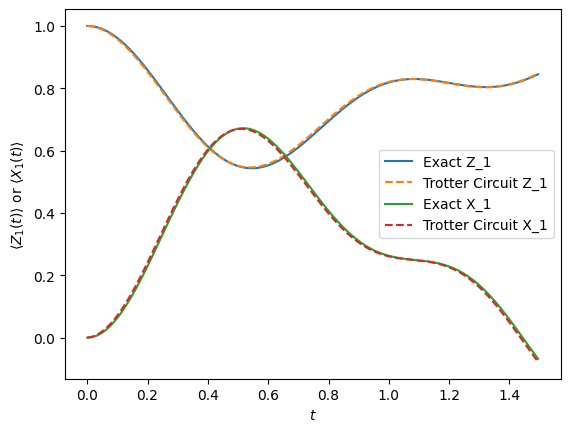

In [23]:
#testing against classicalComparison
L=4
Jz=1.1
dt= 0.5 * 1e-2
numsteps = 300

t_tot = dt*numsteps
tlist1,zlist1 = hm.ClassicalComparison(L,Jz,1,'Z',numsteps,t_tot)
tlist2,zlist2 = TheoreticalST(L,Jz,1,'Z',numsteps,t_tot)
tlist3,xlist3 = hm.ClassicalComparison(L,Jz,1,'X',numsteps,t_tot)
tlist4,xlist4 = TheoreticalST(L,Jz,1,'X',numsteps,t_tot)

# tlist = [0.1 * t for t in range(500)]
plt.plot(tlist1, zlist1, label = 'Exact Z_1')
plt.plot(tlist2, zlist2, '--', label = 'Trotter Circuit Z_1')
plt.plot(tlist3, xlist3, label = 'Exact X_1')
plt.plot(tlist4, xlist4, '--', label = 'Trotter Circuit X_1')
plt.ylabel(r'$\langle Z_1(t) \rangle$ or $\langle X_1(t) \rangle$')
plt.xlabel(r'$t$')
plt.legend()
plt.show()
plt.close()

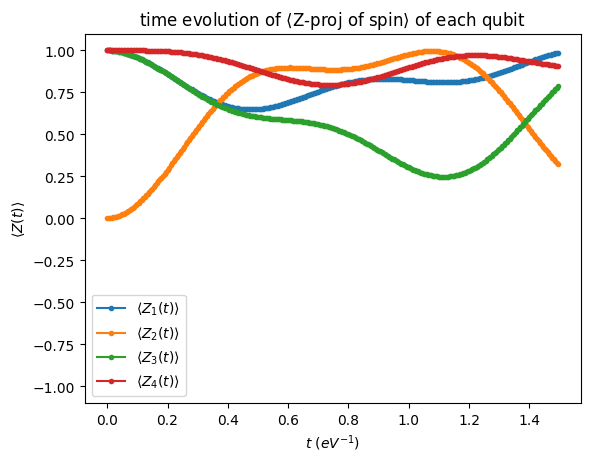

In [24]:
# direction Z
L = 4
Jz = 2
direction = 'Z'
steps = 300
t_tot=t_tot

#number is for the qubit measured
t1,x1 = TheoreticalST(L,Jz,1,direction,steps,t_tot)
t2,x2 = TheoreticalST(L,Jz,2,direction,steps,t_tot)
t3,x3 = TheoreticalST(L,Jz,3,direction,steps,t_tot)
t4,x4 = TheoreticalST(L,Jz,4,direction,steps,t_tot)


plt.plot(t1,x1,'.-',label=r'$\langle Z_1(t) \rangle$')
plt.plot(t2,x2,'.-',label=r'$\langle Z_2(t) \rangle$')
plt.plot(t3,x3,'.-',label=r'$\langle Z_3(t) \rangle$')
plt.plot(t4,x4,'.-',label=r'$\langle Z_4(t) \rangle$')

plt.xlabel(r'$t$ $(eV^{-1})$')
plt.ylabel(r'$\langle Z(t) \rangle$')
plt.legend()
plt.title(r'time evolution of $\langle$Z-proj of spin$\rangle$ of each qubit')
plt.ylim([-1.1,1.1])
plt.show()
plt.close()

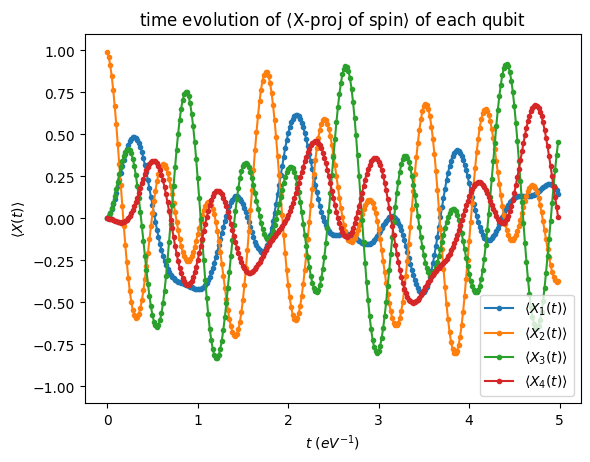

In [ ]:
# takes just over 6m to run
# direction X
L = 4
Jz = 2
direction = 'X'
steps = 300
t_tot=5

#number is for the qubit measured
t1,x1 = TheoreticalST(L,Jz,1,direction,steps,t_tot)
t2,x2 = TheoreticalST(L,Jz,2,direction,steps,t_tot)
t3,x3 = TheoreticalST(L,Jz,3,direction,steps,t_tot)
t4,x4 = TheoreticalST(L,Jz,4,direction,steps,t_tot)


plt.plot(t1,x1,'.-',label=r'$\langle X_1(t) \rangle$')
plt.plot(t2,x2,'.-',label=r'$\langle X_2(t) \rangle$')
plt.plot(t3,x3,'.-',label=r'$\langle X_3(t) \rangle$')
plt.plot(t4,x4,'.-',label=r'$\langle X_4(t) \rangle$')

plt.xlabel(r'$t$ $(eV^{-1})$')
plt.ylabel(r'$\langle X(t) \rangle$')
plt.legend()
plt.title(r'time evolution of $\langle$X-proj of spin$\rangle$ of each qubit')
plt.ylim([-1.1,1.1])
plt.show()
plt.close()

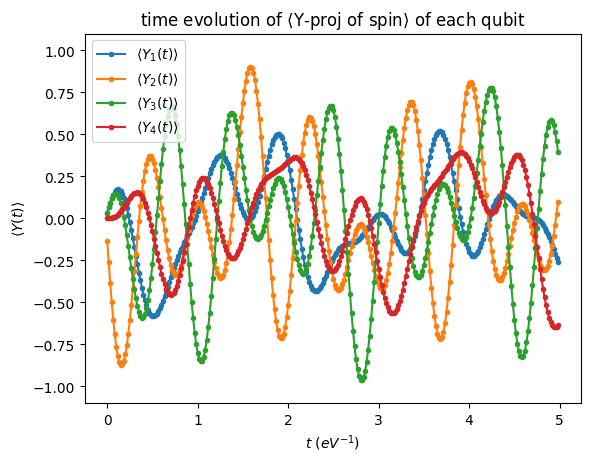

In [26]:
#takes just over 5m to run
# direction Y
L = 4
Jz = 2
direction = 'Y'
steps = 300
t_tot=5

#number is for the qubit measured
t1,x1 = TheoreticalST(L,Jz,1,direction,steps,t_tot)
t2,x2 = TheoreticalST(L,Jz,2,direction,steps,t_tot)
t3,x3 = TheoreticalST(L,Jz,3,direction,steps,t_tot)
t4,x4 = TheoreticalST(L,Jz,4,direction,steps,t_tot)


plt.plot(t1,x1,'.-',label=r'$\langle Y_1(t) \rangle$')
plt.plot(t2,x2,'.-',label=r'$\langle Y_2(t) \rangle$')
plt.plot(t3,x3,'.-',label=r'$\langle Y_3(t) \rangle$')
plt.plot(t4,x4,'.-',label=r'$\langle Y_4(t) \rangle$')

plt.xlabel(r'$t$ $(eV^{-1})$')
plt.ylabel(r'$\langle Y(t) \rangle$')
plt.legend()
plt.title(r'time evolution of $\langle$Y-proj of spin$\rangle$ of each qubit')
plt.ylim([-1.1,1.1])
plt.show()
plt.close()

# NEXT PART
okay, build a function that does this, but keeps trotter circuit the same (ex. 5 reps), and changes dt to get diffeernt results

In [36]:
def PhysicalST(L,Jz,qubit_measured,direction_measured,steps,t_tot,order=1,reps=5,allzeros=True):
    '''
    Performs ST with qiskit's built-in function (with order ``order``), with ``reps`` repetitions of timestep dt.
    To build results list, runs this ST circuit with fixed reps, changing dt, so final time of single ST circuit runs over `steps` values from 0 `t_tot`
    Circuit depth stays the same, but a new circuit is initialized to build each timestep measurement result

    returns 

    Parameters
    ----------
    L : int
        number of qubits

    Jz : float
        J_z value
     
    qubit_measured : (int) 
        which qubit (1 to L) is measured

    direction_measured : (str) 
        "X" "Y" or "Z", which projection operator is applied to the measured qubit
    steps : (int) 
        number of time steps
    t_tot : (float) 
        total time (in seconds? not seconds 'cause there are no hbars or cs)
    order : int
        order qiskit's Suzuki Trotter method. Autoset to 1
    reps : int
        repetitions of qiskit's Suzuki Trotter timestep, within the built in function. This is the fixed circuit depth for the whole thing. Autoset to 5
    allzeros : (bool) 
        if Jz>1, True chooses the all |0> state, False chooses the all |1> state. Autoset to True

    Returns
    -------
    Tuple
        Tuple of arrays containing (t_steps,measurements)
    '''
    #creating hamiltonian
    hamiltonian = hm.hamiltonian1(L,Jz)

    #Setting order and reps of SuzukiTrotter method
    st = SuzukiTrotter(order=order, reps=reps)

    # Define the observable we wish to estimate
    paulistring=""
    for i in range(L):
        if i == qubit_measured - 1:
            paulistring+=direction_measured
        else:
            paulistring+="I"
    obs = SparsePauliOp([paulistring],coeffs=[1])

    # Define the 'Estimator' primitive used to measure/estimate expectation values of observables
    ### IS THIS WHAT NEEDS TO CHANGE WHEN RUNNING ON IBM?
    estimator = StatevectorEstimator()

    #getting initial state, according to Jz value
    if Jz > 1:
        all0, all1 = hm.initialise(Jz,L)[1]
        if allzeros==True:
            initial = all0
        else:
            initial = all1
    elif Jz < -1:
        initial = hm.initialise(Jz,L)[1][0]
    else:
        raise ValueError('Please pick J_z > 1 or J_z < -1')

    #rotating middle qubit's spin to x-y plane
    qc = QuantumCircuit(int(L))
    qc.initialize(initial) #initialize state
    #apply rotation
    middle = L //2 #picks L/2 int value
    qc.ry(np.pi/2, middle) #rotation here is into x-y plane
    initial = Statevector(qc)  #initial state, now rotated

    # Prepare an empty list to store data and run a loop over timesteps
    measurements = []

    #looping over timesteps, initializing a new circuit each time
    dt = t_tot/steps
    t_values = [dt*t for t in range(steps)]
    for timeval in t_values:
        # #dt for ST circuit:
        # dt = timeval/reps

        #making PauliEvolutionGate and ST circuit
        gate = PauliEvolutionGate(operator=hamiltonian,time=timeval)
        circ = st.synthesize(gate)
        #initialize circuit
        qc = QuantumCircuit(int(L))
        qc.initialize(initial) #initialize state
        #appending the ST circuit
        qc.append(circ,[i for i in range(L)])
        pub = (qc, [obs])
        result = estimator.run(pubs=[pub]).result()
        resultval = result[0].data.evs[0]
        measurements += [resultval]
    
    return (np.array(t_values),np.array(measurements))



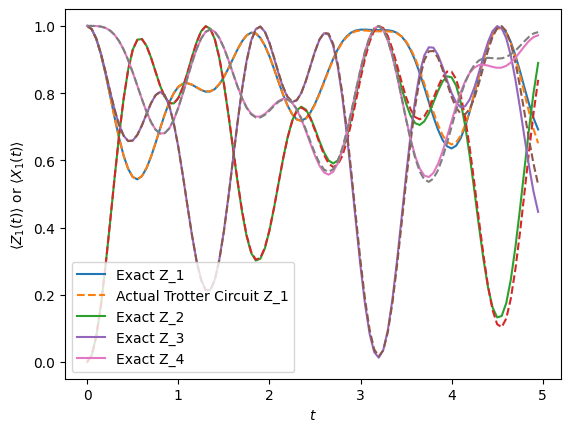

In [45]:
# comparing PhysicalST to Classical Comparison

#testing against classicalComparison
L=4
Jz=1.1
# dt= 0.5 * 1e-2
numsteps = 100  #this doesnt really matter for Physical anymore, reps does -- for goodness of results. Can use this to reduce time it takes to run
reps = 50

t_tot = 5 #dt*numsteps

tlist1,zlist1 = hm.ClassicalComparison(L,Jz,1,'Z',numsteps,t_tot)
tlist2,zlist2 = PhysicalST(L,Jz,1,'Z',numsteps,t_tot,order=2,reps=reps)
tlist3,zlist3 = hm.ClassicalComparison(L,Jz,2,'Z',numsteps,t_tot)
tlist4,zlist4 = PhysicalST(L,Jz,2,'Z',numsteps,t_tot,order=2,reps=reps)
tlist5,zlist5 = hm.ClassicalComparison(L,Jz,3,'Z',numsteps,t_tot)
tlist6,zlist6 = PhysicalST(L,Jz,3,'Z',numsteps,t_tot,order=2,reps=reps)
tlist7,zlist7 = hm.ClassicalComparison(L,Jz,4,'Z',numsteps,t_tot)
tlist8,zlist8 = PhysicalST(L,Jz,4,'Z',numsteps,t_tot,order=2,reps=reps)

# tlist = [0.1 * t for t in range(500)]
plt.plot(tlist1, zlist1, label = 'Exact Z_1')
plt.plot(tlist2, zlist2, '--', label = 'Actual Trotter Circuit Z_1')
plt.plot(tlist3, zlist3, label = 'Exact Z_2')
plt.plot(tlist4, zlist4, '--')#, label = 'Actual Trotter Circuit Z_2')
plt.plot(tlist1, zlist5, label = 'Exact Z_3')
plt.plot(tlist2, zlist6, '--')#, label = 'Actual Trotter Circuit Z_3')
plt.plot(tlist3, zlist7, label = 'Exact Z_4')
plt.plot(tlist4, zlist8, '--')#, label = 'Actual Trotter Circuit Z_4')
plt.ylabel(r'$\langle Z_1(t) \rangle$ or $\langle X_1(t) \rangle$')
plt.xlabel(r'$t$')
plt.legend()
plt.show()
plt.close()

can try different combinations of order and reps to see what gives best result. As can see, can't do accurate results too far into future, because then the dt timesteps within ST are hugeee

timesteps `steps` doesn't actually matter here for goodness of results, it just determines how granular our final data is, determines how many times the ST circuit is rebuilt. So can reduce this to reduce time it takes, if don't need super granular final data. -- speed things up that way

100 reps -- gives exact matching up to t=2.5 at least, but took 4m to run with numsteps = 500 and only two qubits measured

50 reps -- very good up to t = 3.5, took 1.5m to run all four qubits measurement, with 200 numsteps. ; 45s with 100 steps, but the lines are staring to get a bit choppy, not enough data

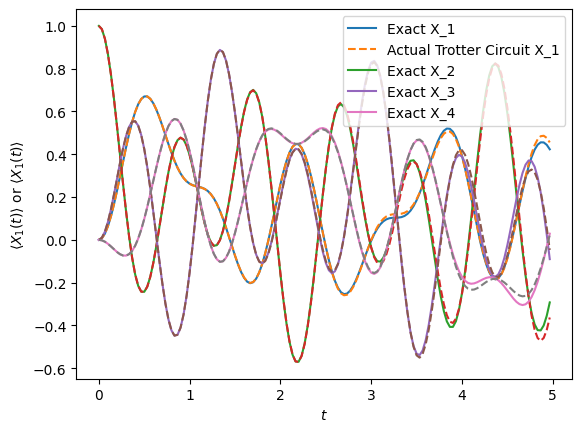

In [46]:
# X spin
# comparing PhysicalST to Classical Comparison

#testing against classicalComparison
L=4
Jz=1.1
# dt= 0.5 * 1e-2
numsteps = 150  #this doesnt really matter for Physical anymore, reps does -- for goodness of results. Can use this to reduce time it takes to run
reps = 50

t_tot = 5 #dt*numsteps

tlist1,zlist1 = hm.ClassicalComparison(L,Jz,1,'X',numsteps,t_tot)
tlist2,zlist2 = PhysicalST(L,Jz,1,'X',numsteps,t_tot,order=2,reps=reps)
tlist3,zlist3 = hm.ClassicalComparison(L,Jz,2,'X',numsteps,t_tot)
tlist4,zlist4 = PhysicalST(L,Jz,2,'X',numsteps,t_tot,order=2,reps=reps)
tlist5,zlist5 = hm.ClassicalComparison(L,Jz,3,'X',numsteps,t_tot)
tlist6,zlist6 = PhysicalST(L,Jz,3,'X',numsteps,t_tot,order=2,reps=reps)
tlist7,zlist7 = hm.ClassicalComparison(L,Jz,4,'X',numsteps,t_tot)
tlist8,zlist8 = PhysicalST(L,Jz,4,'X',numsteps,t_tot,order=2,reps=reps)

# tlist = [0.1 * t for t in range(500)]
plt.plot(tlist1, zlist1, label = 'Exact X_1')
plt.plot(tlist2, zlist2, '--', label = 'Actual Trotter Circuit X_1')
plt.plot(tlist3, zlist3, label = 'Exact X_2')
plt.plot(tlist4, zlist4, '--')#, label = 'Actual Trotter Circuit Z_2')
plt.plot(tlist1, zlist5, label = 'Exact X_3')
plt.plot(tlist2, zlist6, '--')#, label = 'Actual Trotter Circuit Z_3')
plt.plot(tlist3, zlist7, label = 'Exact X_4')
plt.plot(tlist4, zlist8, '--')#, label = 'Actual Trotter Circuit Z_4')
plt.ylabel(r'$\langle X_1(t) \rangle$ or $\langle X_1(t) \rangle$')
plt.xlabel(r'$t$')
plt.legend()
plt.show()
plt.close()

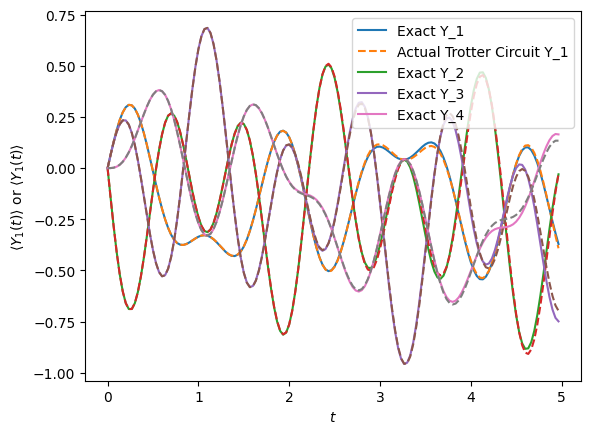

In [47]:
# Y spin
# comparing PhysicalST to Classical Comparison

#testing against classicalComparison
L=4
Jz=1.1
# dt= 0.5 * 1e-2
numsteps = 150  #this doesnt really matter for Physical anymore, reps does -- for goodness of results. Can use this to reduce time it takes to run
reps = 50

t_tot = 5 #dt*numsteps

tlist1,zlist1 = hm.ClassicalComparison(L,Jz,1,'Y',numsteps,t_tot)
tlist2,zlist2 = PhysicalST(L,Jz,1,'Y',numsteps,t_tot,order=2,reps=reps)
tlist3,zlist3 = hm.ClassicalComparison(L,Jz,2,'Y',numsteps,t_tot)
tlist4,zlist4 = PhysicalST(L,Jz,2,'Y',numsteps,t_tot,order=2,reps=reps)
tlist5,zlist5 = hm.ClassicalComparison(L,Jz,3,'Y',numsteps,t_tot)
tlist6,zlist6 = PhysicalST(L,Jz,3,'Y',numsteps,t_tot,order=2,reps=reps)
tlist7,zlist7 = hm.ClassicalComparison(L,Jz,4,'Y',numsteps,t_tot)
tlist8,zlist8 = PhysicalST(L,Jz,4,'Y',numsteps,t_tot,order=2,reps=reps)

# tlist = [0.1 * t for t in range(500)]
plt.plot(tlist1, zlist1, label = 'Exact Y_1')
plt.plot(tlist2, zlist2, '--', label = 'Actual Trotter Circuit Y_1')
plt.plot(tlist3, zlist3, label = 'Exact Y_2')
plt.plot(tlist4, zlist4, '--')#, label = 'Actual Trotter Circuit Z_2')
plt.plot(tlist1, zlist5, label = 'Exact Y_3')
plt.plot(tlist2, zlist6, '--')#, label = 'Actual Trotter Circuit Z_3')
plt.plot(tlist3, zlist7, label = 'Exact Y_4')
plt.plot(tlist4, zlist8, '--')#, label = 'Actual Trotter Circuit Z_4')
plt.ylabel(r'$\langle Y_1(t) \rangle$ or $\langle Y_1(t) \rangle$')
plt.xlabel(r'$t$')
plt.legend()
plt.show()
plt.close()